Imports :
pandas
numpy
matplotlib




In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from plot_congestion_snapshot import plot_congestion_snapshot


Visualizing Congestion

In [2]:
#Time Vector

time_snapshot_request = np.array([30,60,90,120])

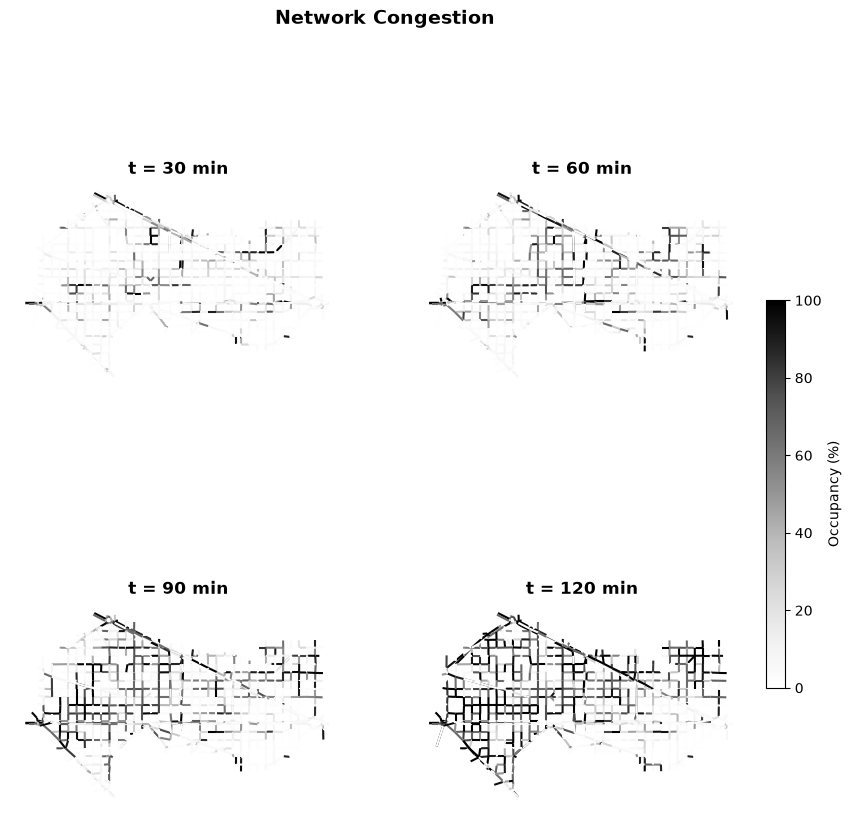

In [3]:
# Execution of provided snapshot function for times 30 sec, 60 sec, 90 sec, and 120 sec

plot_congestion_snapshot(time_snapshot_request)

In [4]:
#Extracting Information from CSV files

df_flow = pd.read_csv("flow.csv")
time_col = df_flow.columns[0]   
df_flow = df_flow.set_index(time_col)
df_flow.columns = df_flow.columns.astype(str)          
veh_per_hour = df_flow.astype(float) * 40  #multiplying by 40 to convert to veh/hr
veh_per_hour.head()


,512,513,514,516,593,594,595,596,597,598,...,64715,64751,64752,68076,69616,69622,70330,72127,73054,73546
0,,,,,,,,,,,,,,,,,,,,,
90,0.0,80.0,0.0,680.0,0.0,720.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,640.0
180,0.0,240.0,120.0,400.0,0.0,840.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,80.0,120.0,40.0,920.0
270,440.0,520.0,320.0,400.0,560.0,840.0,0.0,560.0,560.0,560.0,...,0.0,0.0,0.0,40.0,0.0,320.0,320.0,0.0,0.0,680.0
360,1040.0,520.0,560.0,320.0,1320.0,920.0,0.0,1320.0,1320.0,1280.0,...,0.0,0.0,0.0,0.0,0.0,360.0,360.0,40.0,200.0,600.0
450,800.0,520.0,800.0,600.0,1560.0,640.0,0.0,1560.0,1520.0,1560.0,...,0.0,0.0,0.0,0.0,0.0,200.0,440.0,40.0,40.0,680.0


In [5]:
# Extracting Occupancy from the CSV file

df_occupancy = pd.read_csv("occupancy.csv")
time_col = df_occupancy.columns[0]   
df_occupancy = df_occupancy.set_index(time_col)
df_occupancy.columns = df_occupancy.columns.astype(str)          

df_occupancy.head()


,512,513,514,516,593,594,595,596,597,598,...,64715,64751,64752,68076,69616,69622,70330,72127,73054,73546
0,,,,,,,,,,,,,,,,,,,,,
90,0.000000,0.318851,0.000000,4.498925,0.000000,2.558253,0,0.000000,0.000000,0.000000,...,0,0,0,0.000000,0,0.000000,0.000000,0.000000,0.000000,1.916312
180,0.000000,0.954632,0.689668,2.758188,0.000000,3.160290,0,0.000000,0.000000,0.000000,...,0,0,0,0.000000,0,0.000000,0.496381,0.982652,0.078359,2.815576
270,1.467929,2.044361,1.777651,2.653984,2.062903,3.084929,0,1.971922,1.980655,2.266559,...,0,0,0,1.117895,0,30.543073,1.952041,0.000000,0.000000,2.090327
360,3.901444,2.449490,3.395587,2.203485,5.054119,3.337283,0,4.998530,5.033535,5.931589,...,0,0,0,0.000000,0,33.460783,2.284171,0.213384,1.499035,1.725334
450,3.104570,1.904677,6.112496,5.337937,6.093624,2.410011,0,5.795999,5.859232,7.389288,...,0,0,0,0.000000,0,79.451015,4.677206,0.222318,0.202072,2.163597


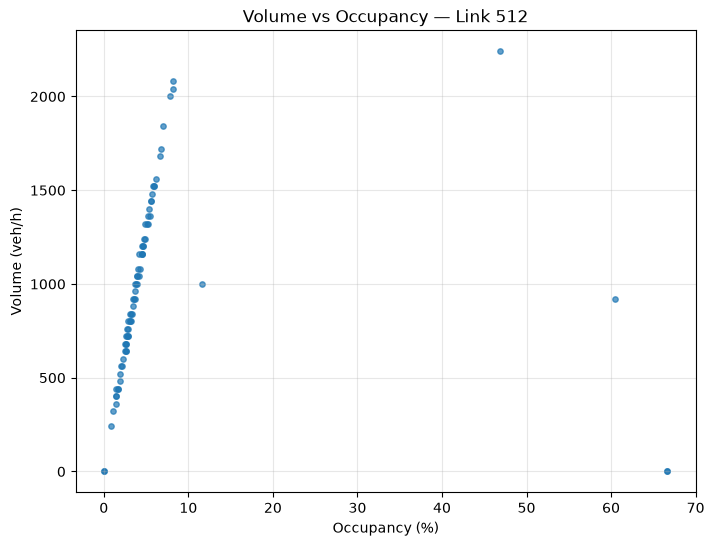

In [6]:
link_id = "512"

occupancy_data = df_occupancy[link_id]
volume_data = veh_per_hour[link_id]

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(occupancy_data, volume_data, s=15, alpha=0.7)
ax.set_xlabel("Occupancy (%)")
ax.set_ylabel("Volume (veh/h)")
ax.set_title(f"Volume vs Occupancy — Link {link_id}")
ax.grid(True, alpha=0.3)    

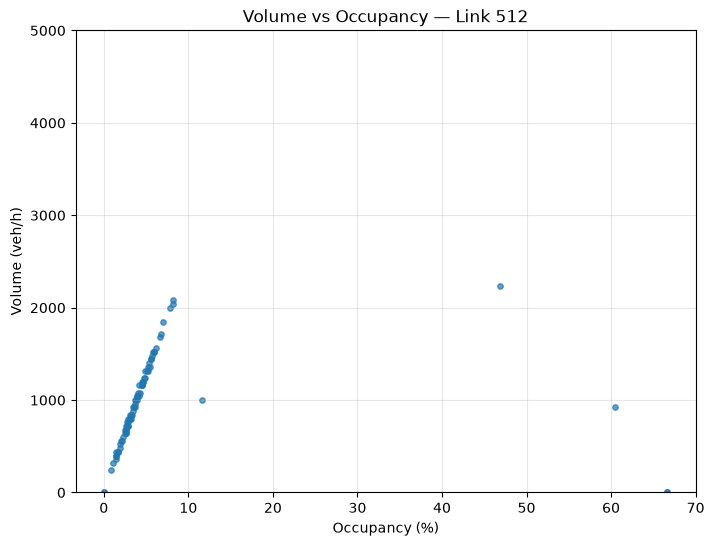

In [7]:
link_id = "512"

occupancy_data = df_occupancy[link_id]
volume_data = veh_per_hour[link_id]

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(occupancy_data, volume_data, s=15, alpha=0.7)
ax.set_ylim(0, 5000)  
ax.set_xlabel("Occupancy (%)")
ax.set_ylabel("Volume (veh/h)")
ax.set_title(f"Volume vs Occupancy — Link {link_id}")
ax.grid(True, alpha=0.3)    


In [17]:
#Extracting Average Occupancy and Average Volume between Links 512 and 513
links_id = ["512", "513"]
average_occupancy = df_occupancy[links_id].mean(axis=1)
average_volume = veh_per_hour[links_id].mean(axis=1)

average_occupancy.head()
average_volume.head()
df_occupancy.head()

,512,513,514,516,593,594,595,596,597,598,...,64715,64751,64752,68076,69616,69622,70330,72127,73054,73546
timestamp,,,,,,,,,,,,,,,,,,,,,
90,0.000000,0.318851,0.000000,4.498925,0.000000,2.558253,0,0.000000,0.000000,0.000000,...,0,0,0,0.000000,0,0.000000,0.000000,0.000000,0.000000,1.916312
180,0.000000,0.954632,0.689668,2.758188,0.000000,3.160290,0,0.000000,0.000000,0.000000,...,0,0,0,0.000000,0,0.000000,0.496381,0.982652,0.078359,2.815576
270,1.467929,2.044361,1.777651,2.653984,2.062903,3.084929,0,1.971922,1.980655,2.266559,...,0,0,0,1.117895,0,30.543073,1.952041,0.000000,0.000000,2.090327
360,3.901444,2.449490,3.395587,2.203485,5.054119,3.337283,0,4.998530,5.033535,5.931589,...,0,0,0,0.000000,0,33.460783,2.284171,0.213384,1.499035,1.725334
450,3.104570,1.904677,6.112496,5.337937,6.093624,2.410011,0,5.795999,5.859232,7.389288,...,0,0,0,0.000000,0,79.451015,4.677206,0.222318,0.202072,2.163597


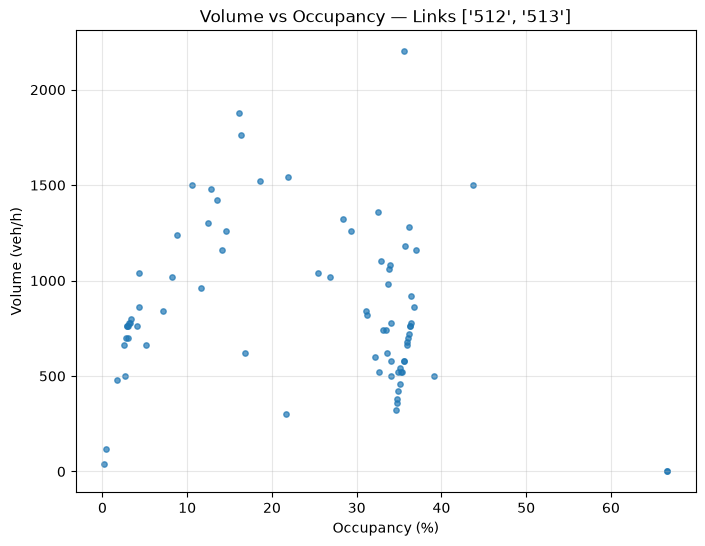

In [9]:
#plotting the averages


fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(average_occupancy, average_volume, s=15, alpha=0.7)
## ax.set_ylim(0, 5000)  only use for scale
ax.set_xlabel("Occupancy (%)")
ax.set_ylabel("Volume (veh/h)")
ax.set_title(f"Volume vs Occupancy — Links {links_id}")
ax.grid(True, alpha=0.3)    

In [18]:
# create a link table for each region
df_links = pd.read_csv("links.csv",header=None, names=["link_id", "length_m", "num_lanes", "start_node", "end_node", "region"])
df_links["link_id"] = df_links["link_id"].astype(str) #to make sure the link ids dont get mixed up in the other numbers
df_links["region"] = df_links["region"].astype(str) #to make sure the region ids dont get mixed up in the other numbers

region_volume = {}    
region_occupancy = {}

for region in df_links["region"].unique():
    links_in_region = df_links.loc[df_links["region"] == region, "link_id"]

    region_volume[region] = veh_per_hour[links_in_region]
    region_occupancy[region] = df_occupancy[links_in_region]

df_occupancy.head()

,512,513,514,516,593,594,595,596,597,598,...,64715,64751,64752,68076,69616,69622,70330,72127,73054,73546
timestamp,,,,,,,,,,,,,,,,,,,,,
90,0.000000,0.318851,0.000000,4.498925,0.000000,2.558253,0,0.000000,0.000000,0.000000,...,0,0,0,0.000000,0,0.000000,0.000000,0.000000,0.000000,1.916312
180,0.000000,0.954632,0.689668,2.758188,0.000000,3.160290,0,0.000000,0.000000,0.000000,...,0,0,0,0.000000,0,0.000000,0.496381,0.982652,0.078359,2.815576
270,1.467929,2.044361,1.777651,2.653984,2.062903,3.084929,0,1.971922,1.980655,2.266559,...,0,0,0,1.117895,0,30.543073,1.952041,0.000000,0.000000,2.090327
360,3.901444,2.449490,3.395587,2.203485,5.054119,3.337283,0,4.998530,5.033535,5.931589,...,0,0,0,0.000000,0,33.460783,2.284171,0.213384,1.499035,1.725334
450,3.104570,1.904677,6.112496,5.337937,6.093624,2.410011,0,5.795999,5.859232,7.389288,...,0,0,0,0.000000,0,79.451015,4.677206,0.222318,0.202072,2.163597


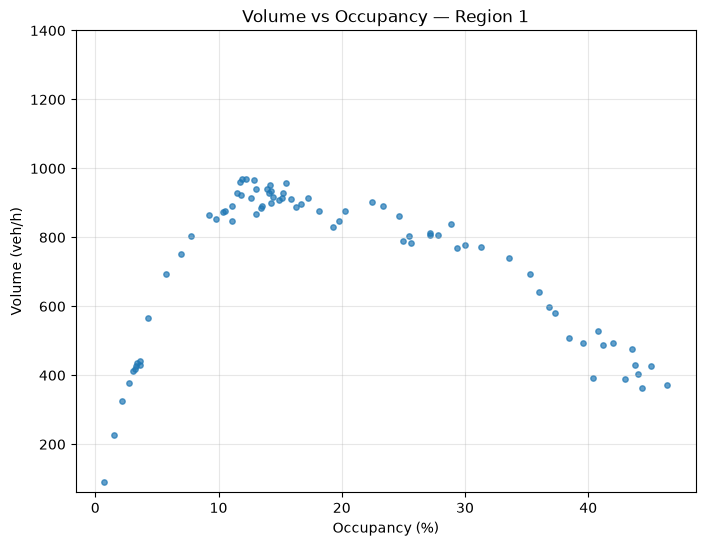

In [11]:
region = "1" #using same plotting process as before for each region



average_occupancy = region_occupancy[region].mean(axis=1)
average_volume = region_volume[region].mean(axis=1)

average_occupancy.head()
average_volume.head()
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(average_occupancy, average_volume, s=15, alpha=0.7)
ax.set_ylim(60, 1400) #use only for scale
ax.set_xlabel("Occupancy (%)")
ax.set_ylabel("Volume (veh/h)")
ax.set_title(f"Volume vs Occupancy — Region {region}")
ax.grid(True, alpha=0.3)    

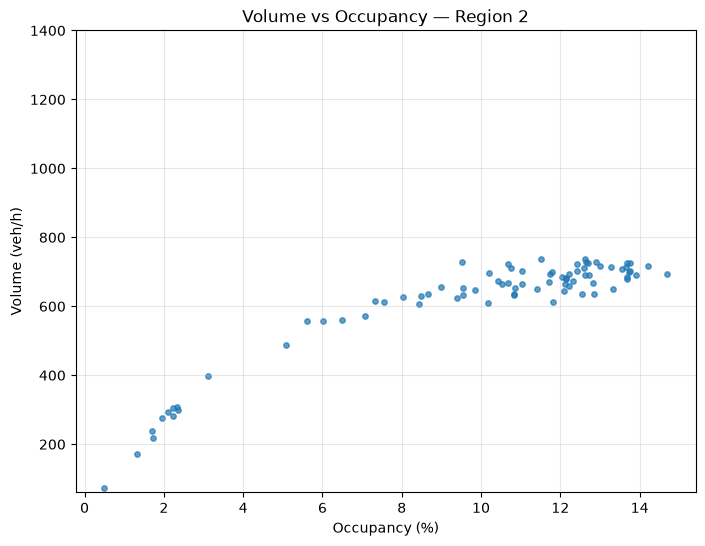

In [12]:
region = "2" #using same plotting process as before for each region



average_occupancy = region_occupancy[region].mean(axis=1)
average_volume = region_volume[region].mean(axis=1)

average_occupancy.head()
average_volume.head()
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(average_occupancy, average_volume, s=15, alpha=0.7)
## ax.set_ylim(0, 5000)  only use for scale
ax.set_ylim(60, 1400) #use only for scale
ax.set_xlabel("Occupancy (%)")
ax.set_ylabel("Volume (veh/h)")
ax.set_title(f"Volume vs Occupancy — Region {region}")
ax.grid(True, alpha=0.3)    

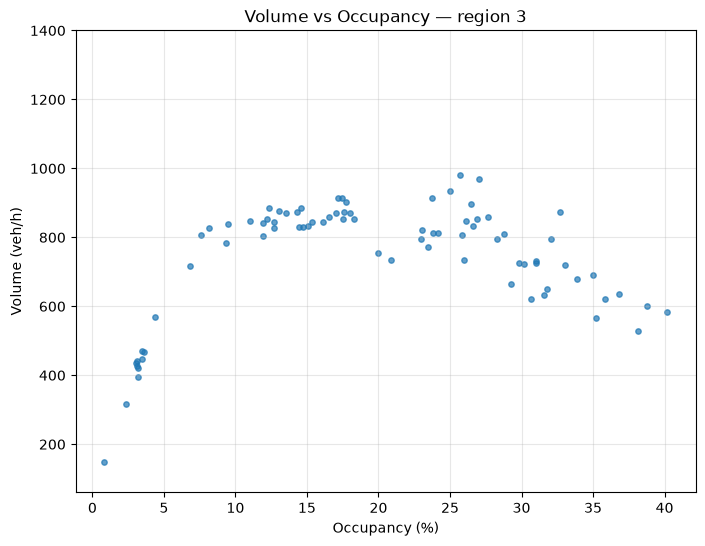

In [13]:
region = "3" #using same plotting process as before for each region



average_occupancy = region_occupancy[region].mean(axis=1)
average_volume = region_volume[region].mean(axis=1)

average_occupancy.head()
average_volume.head()
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(average_occupancy, average_volume, s=15, alpha=0.7)
## ax.set_ylim(0, 5000)  only use for scale
ax.set_ylim(60, 1400) #use only for scale
ax.set_xlabel("Occupancy (%)")
ax.set_ylabel("Volume (veh/h)")
ax.set_title(f"Volume vs Occupancy — region {region}")
ax.grid(True, alpha=0.3)    

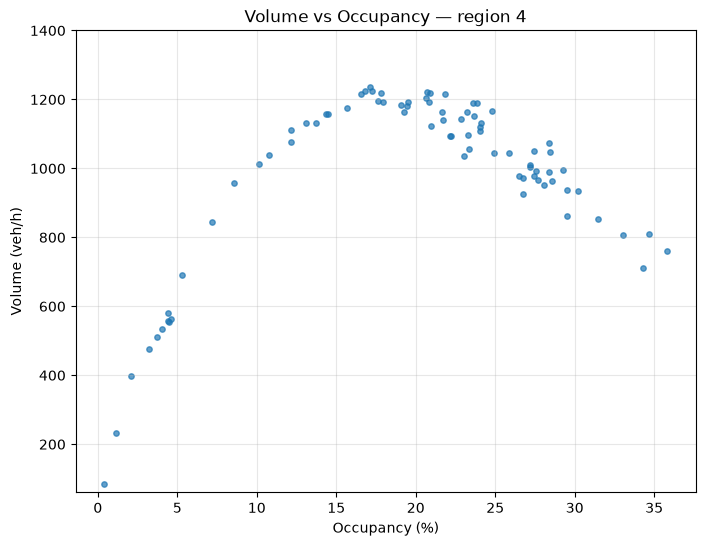

In [14]:
region = "4" #using same plotting process as before for each region



average_occupancy = region_occupancy[region].mean(axis=1)
average_volume = region_volume[region].mean(axis=1)

average_occupancy.head()
average_volume.head()
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(average_occupancy, average_volume, s=15, alpha=0.7)
## ax.set_ylim(0, 5000)  only use for scale
ax.set_ylim(60, 1400) #use only for scale
ax.set_xlabel("Occupancy (%)")
ax.set_ylabel("Volume (veh/h)")
ax.set_title(f"Volume vs Occupancy — region {region}")
ax.grid(True, alpha=0.3)    

In [23]:
df_occupancy.head()

,512,513,514,516,593,594,595,596,597,598,...,64715,64751,64752,68076,69616,69622,70330,72127,73054,73546
timestamp,,,,,,,,,,,,,,,,,,,,,
90,0.000000,0.318851,0.000000,4.498925,0.000000,2.558253,0,0.000000,0.000000,0.000000,...,0,0,0,0.000000,0,0.000000,0.000000,0.000000,0.000000,1.916312
180,0.000000,0.954632,0.689668,2.758188,0.000000,3.160290,0,0.000000,0.000000,0.000000,...,0,0,0,0.000000,0,0.000000,0.496381,0.982652,0.078359,2.815576
270,1.467929,2.044361,1.777651,2.653984,2.062903,3.084929,0,1.971922,1.980655,2.266559,...,0,0,0,1.117895,0,30.543073,1.952041,0.000000,0.000000,2.090327
360,3.901444,2.449490,3.395587,2.203485,5.054119,3.337283,0,4.998530,5.033535,5.931589,...,0,0,0,0.000000,0,33.460783,2.284171,0.213384,1.499035,1.725334
450,3.104570,1.904677,6.112496,5.337937,6.093624,2.410011,0,5.795999,5.859232,7.389288,...,0,0,0,0.000000,0,79.451015,4.677206,0.222318,0.202072,2.163597


In [26]:
lanes_per_link = df_links.set_index("link_id")["num_lanes"]

# Density = occupancy * lanes / 700, per link, per timestamp
df_density = df_occupancy.multiply(lanes_per_link, axis=1) / 0.7
df_density.index.name = "timestamp"
df_density.columns = df_density.columns.astype(str)

df_density.head()

,512,513,514,516,593,594,595,596,597,598,...,64715,64751,64752,68076,69616,69622,70330,72127,73054,73546
timestamp,,,,,,,,,,,,,,,,,,,,,
90,0.000000,1.366504,0.000000,12.854070,0.000000,10.963941,0.0,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,8.212767
180,0.000000,4.091281,1.970480,7.880537,0.000000,13.544099,0.0,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.000000,0.0,0.000000,1.418231,2.807576,0.223884,12.066754
270,6.291124,8.761549,5.079003,7.582813,8.841014,13.221123,0.0,8.451094,8.488520,9.713826,...,0.0,0.0,0.0,1.596993,0.0,43.632961,5.577259,0.000000,0.000000,8.958546
360,16.720473,10.497813,9.701679,6.295670,21.660510,14.302640,0.0,21.422270,21.572291,25.421096,...,0.0,0.0,0.0,0.000000,0.0,47.801119,6.526204,0.609667,4.282956,7.394289
450,13.305301,8.162903,17.464276,15.251249,26.115533,10.328620,0.0,24.839994,25.110993,31.668379,...,0.0,0.0,0.0,0.000000,0.0,113.501450,13.363444,0.635193,0.577350,9.272560


In [ ]:
# Speed (km/h) = Volume (veh/h) / Density (veh/km)
df_speed = veh_per_hour / df_density
df_speed = df_speed.replace([np.inf, -np.inf], np.nan)   # guard against divide-by-zero when density is 0
df_speed.index.name = "timestamp"
df_speed.columns = df_speed.columns.astype(str)

df_speed.head()